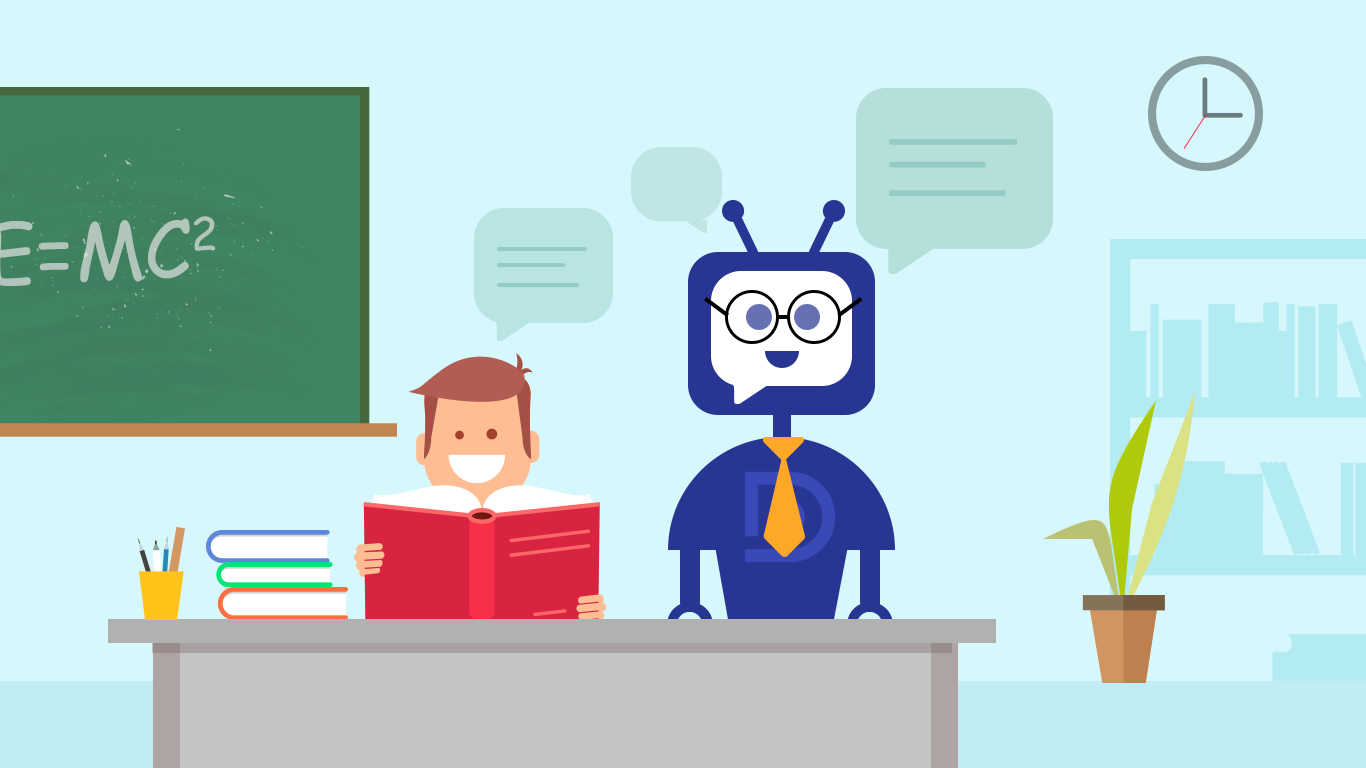

**Special Topics in AI 3 Final Project (Simple Student assistant Chatbot)**

API test OK: OK
The chat conversation started
Commands to implement:
exit: stop conversation
reset: clear the chat memory
export: save logs to chatbot_logs_testing.csv
evaluate: to show plots and tables for evaluation

You: hello
Bot: Hello! How can I assist you today with questions about deadlines, submissions, grading, office hours, or university policies?
You: What can you help me with?
Bot: I can help you with questions about deadlines, submissions, grading, office hours, and university policies.
You: And how about grades?
Bot: I can help you with questions about grades.
You: Can you help me calculate grades?
Bot: I can help you calculate your grades! To use the calculator tool, I need specific details about your marks and the weighting of each assessment component (e.g., assignment scores, exam percentages, quiz weights).

Please provide this information so I can perform the calculation.
You: Calculate 30% of 90
Bot: Using the calculator, 30% of 90 is 27.0.
You: Calculate (0.4 * 7

,timestamp,tool_used,user_query,tool_input,tool_output
0,2026-01-26T18:15:04.833101+00:00,NONE,hello,,
1,2026-01-26T18:15:27.651419+00:00,NONE,What can you help me with?,,
2,2026-01-26T18:15:43.774822+00:00,NONE,And how about grades?,,
3,2026-01-26T18:16:58.245266+00:00,CALCULATOR,Can you help me calculate grades?,,Calculator error: no expression found
4,2026-01-26T18:17:21.424089+00:00,CALCULATOR,Calculate 30% of 90,(30%)*(90),27.0


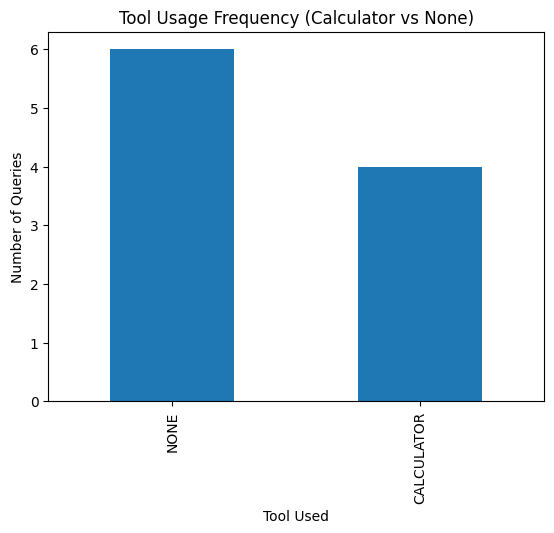

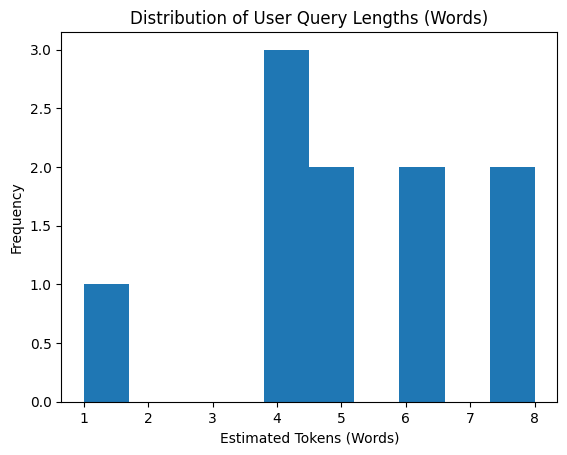


Evaluation Done!
You: export
Logs exported to: chatbot_logs_testing.csv
Bot: The logs exported successfully
You: exit
The chat conversation ended


In [6]:
# Install the appropriate vesions to align with Google Collab
!pip -q install -U "google-genai" "pandas==2.2.2" "google-auth==2.43.0" "matplotlib==3.8.4"
# Put the API key in secure way not hard-coded, configuration files, and error handling
from google.colab import userdata
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError(
        "The Key is missing and not added to the secret folder so please add it and restart the runtime"
    )
# Importing Neccessary Libraries
from google import genai
from google.genai import errors
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import re
import math
# Initilize the gemini client
client = genai.Client(api_key=GEMINI_API_KEY)
# Initilize the model that we will use depending on the availabe models from Gemini
MODEL = "gemini-2.5-flash"
# These rules are given for the Model before the user message to make them specialized on the scope of our problem and provide relevant and coherent responses
SYSTEM_PROMPT = (
    "You are a university Student Support Chatbot.\n"
    "Rules:\n"
    "1) Answer only student support questions (deadlines, submissions, grading, office hours, policies).\n"
    "2) If you are unsure, say you are not sure and advise checking official channels (LMS/instructor).\n"
    "3) If a question requires calculation (marks, percentages, weighted averages), you MUST use the CALCULATOR tool result.\n"
    "4) Keep answers concise, clear, and professional.\n"
)
# The transcript is to enable the multi-turn converstaion so it asts as memory and remember the chats preserving context across user turns
transcript = f"System: {SYSTEM_PROMPT}\n"
# Here we have implemented one agent-like capability which is tool usage (calculator)
# Allowing the calculator to accept only numerical expressions
ALLOWED_CHARS = set("0123456789+-*/(). %")
# This function is the calculator tool
def calculator(expression: str) -> str:
    expr = (expression or "").strip()
    if not expr:
        return "Calculator error: no expression found"
    if any(ch not in ALLOWED_CHARS for ch in expr):
        return "Calculator error: invalid characters in expression"
    # Convert % to /100
    expr = re.sub(r"(\d+(\.\d+)?)\s*%", r"(\1/100)", expr)
    try:
        result = eval(expr, {"__builtins__": {}}, {"math": math})
        return str(result)
    except Exception:
        return "Calculator error: could not evaluate expression"
# This function to know if the the user message require the calculator tool or not
def needs_calculation(query: str) -> bool:
    q = query.lower()
    patterns = [
        r"\bcalculate\b",
        r"\bpercentage\b",
        r"\baverage\b",
        r"\bweight\b",
        r"\bweighted\b",
        r"\bmark\b",
        r"\bgrade\b",
        r"[%]",
        r"\d+\s*[\+\-\*/]" # Arithmetic Calculation
    ]
    return any(re.search(p, q) for p in patterns)
# This function to take a natural-language question and extract a mathematical expression that the calculator tool can compute
def extract_expression(user_input: str) -> str:
    text = user_input.lower().strip()
    m = re.search(r"(\d+(\.\d+)?)\s*%\s*of\s*(\d+(\.\d+)?)", text)
    if m:
        pct = m.group(1)
        val = m.group(3)
        return f"({pct}%)*({val})" # The calculator () function with convert % to /100
    matches = re.findall(r"[\d\.\s\+\-\*\/\(\)%]+", user_input)
    return matches[0].strip() if matches else ""
# The logging phase for evaluation process
LOG_ENABLED = True
logs = []
def now_utc_iso():
    return datetime.now(timezone.utc).isoformat()
# Storing the testing set of prompts and outputs for evaluation
def log_interaction(user_q: str, tool_used: str, tool_input: str, tool_output: str, answer: str):
    if not LOG_ENABLED:
        return
    logs.append({
        "timestamp": now_utc_iso(),
        "user_query": user_q,
        "tool_used": tool_used, # "CALCULATOR" or "NONE"
        "tool_input": tool_input, # the expression passed to calculator
        "tool_output": tool_output, # calculator result
        "assistant_response": answer,
        "model": MODEL,
        "query_length_chars": len(user_q),
        "estimated_tokens_words": len(user_q.split()),
    })
# Export the logs into csv for evaluation
def export_logs(csv_path: str = "chatbot_logs.csv"):
    if not logs:
        print("No logs to export yet")
        return
    pd.DataFrame(logs).to_csv(csv_path, index=False)
    print(f"Logs exported to: {csv_path}")
# Evaluation function using pandas and matplotlib
def evaluate_logs():
    if not logs:
        print("No logs yet. Ask a few questions first, then run evaluate")
        return
    df = pd.DataFrame(logs)
    print("\nSample of the log table (The first five rows)")
    display(df[["timestamp", "tool_used", "user_query", "tool_input", "tool_output"]].head())
    # The first plot which is the tool usage frequency
    tool_counts = df["tool_used"].value_counts()
    plt.figure()
    tool_counts.plot(kind="bar")
    plt.title("Tool Usage Frequency (Calculator vs None)")
    plt.xlabel("Tool Used")
    plt.ylabel("Number of Queries")
    plt.show()
    # The second plot which is the query length distribution
    plt.figure()
    plt.hist(df["estimated_tokens_words"], bins=10)
    plt.title("Distribution of User Query Lengths (Words)")
    plt.xlabel("Estimated Tokens (Words)")
    plt.ylabel("Frequency")
    plt.show()
    print("\nEvaluation Done!")
# The main function of the chatbot
def ask_chatbot(user_input: str) -> str:
    """
    Multi-turn chatbot:
    - Keeps transcript for context
    - If calculation intent is detected:
        1) Use calculator tool
        2) Ask LLM to explain and present the final answer using tool result
    - Otherwise:
        Ask LLM normally under system prompt constraints
    """
    global transcript
    if not user_input or not user_input.strip():
        return "Please type a valid question."
    user_input = user_input.strip()
    # The tool usage path
    if needs_calculation(user_input):
        expr = extract_expression(user_input)
        calc_result = calculator(expr)
        # Build a short prompt that forces the model to use the tool result
        prompt = (
            f"{SYSTEM_PROMPT}\n"
            f"User question: {user_input}\n"
            f"CALCULATOR tool expression: {expr}\n"
            f"CALCULATOR tool result: {calc_result}\n"
            "Provide a short explanation and the final answer. "
            "Do not redo the math. Use the calculator result."
        )
        try:
            resp = client.models.generate_content(model=MODEL, contents=prompt)
            answer = (resp.text or "").strip() or f"Result: {calc_result}"
        except errors.APIError as e:
            answer = f"Error ({e.code}): {e.message}"
        # Update the memory for multi-turn conversations
        transcript += f"User: {user_input}\nAssistant: {answer}\n"
        # Log
        log_interaction(user_input, "CALCULATOR", expr, calc_result, answer)
        return answer
    # The normal LLM use and the memory is preserved
    transcript += f"User: {user_input}\nAssistant:"
    try:
        resp = client.models.generate_content(model=MODEL, contents=transcript)
        answer = (resp.text or "").strip() or "I could not generate a response. Please try again."
        transcript += f" {answer}\n"
        log_interaction(user_input, "NONE", "", "", answer)
        return answer
    except errors.APIError as e:
        # Rollback incomplete assistant marker
        cut = transcript.rfind("\nAssistant:")
        if cut != -1:
            transcript = transcript[:cut] + "\n"
        return f"Error ({e.code}): {e.message}"
# Reset the chat memory function
def reset_conversation():
    global transcript
    transcript = f"System: {SYSTEM_PROMPT}\n"
# This function is created for fast check on the API if it's working or not
def quick_api_test():
    try:
        resp = client.models.generate_content(model=MODEL, contents="Say OK in one word.")
        print("API test OK:", (resp.text or "").strip())
    except errors.APIError as e:
        print("API test FAILED")
        print("STATUS:", e.code)
        print("MESSAGE:", e.message)
quick_api_test()
# To start interactive chat
print("The chat conversation started")
print("Commands to implement:")
print("exit: stop conversation")
print("reset: clear the chat memory")
print("export: save logs to chatbot_logs_testing.csv")
print("evaluate: to show plots and tables for evaluation\n")
while True:
    user_q = input("You: ").strip()
    if user_q.lower() in {"exit", "quit"}:
        break
    if user_q.lower() == "reset":
        reset_conversation()
        print("Bot: chat cleared")
        continue
    if user_q.lower() == "export":
        export_logs("chatbot_logs_testing.csv")
        print("Bot: The logs exported successfully")
        continue
    if user_q.lower() == "evaluate":
        evaluate_logs()
        continue
    print("Bot:", ask_chatbot(user_q))
print("The chat conversation ended")